---
title: The trend as a state-space model
short_title: 17 · Markov GP trend
subtitle: Kalman recursions instead of sampling a latent path
---

# Sampling 228 numbers to draw one curve

Notebook 12 fits a smooth warming trend to Albacete's 115 annual maxima. The
model is a local linear trend — an integrated random walk on the GEV location —
and NumPyro handles it the direct way: the path is built from $2(n-1) = 228$
non-centred innovations, and NUTS samples all of them alongside the
hyperparameters. It works, and it takes about five minutes for that one cell.

But a GP on a **line** has structure a GP on a map does not. A one-dimensional
Gauss-Markov process can be written as a linear stochastic differential
equation, and then the posterior over the whole path follows from a **Kalman
filter and smoother** in $O(n)$ — no sampling of the path at all. That is the
state-space view, and `pyrox-gp` exposes it as `MarkovGPPrior` with a family of
SDE kernels.

This notebook asks whether that machinery can do notebook 12's job faster, and
what it costs in fidelity. There is a catch worth stating before we start, and
it shapes everything below.


In [1]:
from __future__ import annotations

import time
import warnings

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
jax.config.update("jax_enable_x64", True)
sns.set_theme(style="whitegrid", context="notebook")

import numpyro
import pyrox_gp as P
from xtremax import GeneralizedExtremeValueDistribution as GEV
from spatial_extremes import data

In [2]:
years, maxima, meta = data.load_single_station()
yr = np.asarray(years, float)
y_np = np.asarray(maxima, float)
y = jnp.asarray(y_np)
n = y.size
y_mean, y_std = float(np.mean(y_np)), float(np.std(y_np))

print("source:", "REAL CDS" if meta["is_real"] else "synthetic")
print(f"{meta['name']} — id {meta['station_id']}, {n} annual maxima, "
      f"{yr.min():.0f}-{yr.max():.0f}")
print(f"maxima {y_np.min():.1f}-{y_np.max():.1f} degC, mean {y_mean:.2f}")

source: REAL CDS
Albacete — id SP000008280, 115 annual maxima, 1901-2025
maxima 35.0-45.0 degC, mean 38.78


## The catch: no integrated-Wiener kernel

Notebook 12's prior is an **integrated random walk** — the local linear trend.
Its defining property is that it is *non-stationary*: the variance grows without
bound, which is exactly what you want from "the climate may drift anywhere, but
smoothly".

Every SDE kernel `pyrox-gp` ships — `MaternSDE`, `PeriodicSDE`, `CosineSDE`,
`ConstantSDE` and their sums and products — is **stationary**, and a stationary
state-space model needs a finite $P_\infty$ that an integrated random walk does
not have. So the local linear trend cannot be expressed here, and notebook 12's
hand-rolled `scan` is not an oversight: it is currently the only way to write
that prior.

What we can do instead is substitute a **long-lengthscale Matern**, which is a
stationary prior that is nonetheless very smooth over a century. That is a real
modelling change, not just a computational one, and notebook 12 gives us a
reason to be nervous about it: its own experiment showed a *free* stationary GP
over-fitting the record badly. We will come back to that.


In [3]:
print("SDE kernels available:", [k for k in dir(P) if k.endswith("SDE")])
print("Markov inference strategies:",
      [k for k in dir(P) if "Markov" in k and "Inference" in k or
       k in ("PosteriorLinearizationMarkov", "ExpectationPropagationMarkov")])

# Fix the GEV scale and shape so every method below solves the same problem:
# only the trend is being inferred, exactly as in the benchmark of notebook 13.
SIGMA, XI = y_std * 0.8, -0.10
print(f"\nfixed for the comparison: sigma = {SIGMA:.2f} degC, xi = {XI:+.2f}")

lik = P.DistLikelihood(
    lambda f: GEV(loc=f + y_mean, scale=SIGMA, concentration=XI))
times = jnp.asarray(yr)
y_centred = y - y_mean

SDE kernels available: ['ConstantSDE', 'CosineSDE', 'MaternSDE', 'PeriodicSDE', 'ProductSDE', 'QuasiPeriodicSDE', 'SumSDE']
Markov inference strategies: ['ExpectationPropagationMarkov', 'GaussNewtonMarkovInference', 'LaplaceMarkovInference', 'PosteriorLinearizationMarkov']

fixed for the comparison: sigma = 1.35 degC, xi = -0.10


## Kalman inference, three ways

The GEV likelihood is not Gaussian, so a plain Kalman smoother does not apply
directly. The Markov strategies handle that the same way their dense
counterparts did in notebook 13 — by replacing the likelihood with Gaussian
sites and iterating — but every operation runs along the time axis in $O(n)$
rather than through an $n\times n$ matrix.

We sweep the kernel's smoothness (`order`) and lengthscale as well, since with
a stationary prior those choices carry the modelling assumptions the local
linear trend made structurally.


In [4]:
CONFIGS = [(1, 60.0), (1, 30.0), (2, 60.0)]
STRATS = [("Laplace", P.LaplaceMarkovInference),
          ("GaussNewton", P.GaussNewtonMarkovInference),
          ("PosteriorLin", P.PosteriorLinearizationMarkov)]

rows, curves = [], {}
for order, ls in CONFIGS:
    sde = P.MaternSDE(variance=jnp.asarray(4.0), lengthscale=jnp.asarray(ls),
                      order=order)
    prior = P.MarkovGPPrior(sde_kernel=sde, times=times)
    for sname, scls in STRATS:
        try:
            t0 = time.time()
            with numpyro.handlers.seed(rng_seed=0):
                cond = prior.condition_nongauss(lik, y_centred, strategy=scls())
                m, v = cond.predict(times)
            dt = time.time() - t0
            mu_t = np.asarray(m) + y_mean
            sd_t = np.sqrt(np.asarray(v))
            warming = mu_t[-15:].mean() - mu_t[:15].mean()
            key = f"Matern-{order} ls={ls:.0f} / {sname}"
            curves[key] = (mu_t, sd_t)
            rows.append({"kernel": f"Matern order {order}, ls {ls:.0f} yr",
                         "strategy": sname, "warming (degC)": warming,
                         "mean sd": sd_t.mean(), "time (s)": dt})
        except Exception as exc:
            rows.append({"kernel": f"Matern order {order}, ls {ls:.0f} yr",
                         "strategy": sname, "warming (degC)": np.nan,
                         "mean sd": np.nan, "time (s)": np.nan})
            print(f"  {sname} failed: {type(exc).__name__}")

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))
print("\nnotebook 12 (local linear trend, NUTS over 228 innovations):")
print("  warming +1.21 degC (95% CI +0.26, +2.15), about 320 s for that cell")

                  kernel     strategy  warming (degC)  mean sd  time (s)
Matern order 1, ls 60 yr      Laplace           1.157    0.292    28.490
Matern order 1, ls 60 yr  GaussNewton           1.157    0.292    12.945
Matern order 1, ls 60 yr PosteriorLin           0.651    0.050    24.624
Matern order 1, ls 30 yr      Laplace           1.123    0.358    14.415
Matern order 1, ls 30 yr  GaussNewton           1.123    0.358    13.992
Matern order 1, ls 30 yr PosteriorLin           0.634    0.064    18.825
Matern order 2, ls 60 yr      Laplace           1.156    0.256    18.925
Matern order 2, ls 60 yr  GaussNewton           1.156    0.256    15.922
Matern order 2, ls 60 yr PosteriorLin           0.680    0.037    20.628

notebook 12 (local linear trend, NUTS over 228 innovations):
  warming +1.21 degC (95% CI +0.26, +2.15), about 320 s for that cell


### Reading the table

Two things stand out, and both echo notebook 13.

**Gauss-Newton and Laplace agree to the digit, and Gauss-Newton is faster.**
That was true for the dense spatial problem too. When both are available, there
is little reason to pay for Laplace.

**Posterior linearisation is the odd one out again.** It reports a smaller
warming *and* a much smaller posterior standard deviation — confidence that the
other two do not share. In notebook 13 it was likewise an outlier, and there it
also failed outright on the bounded-tail problem. Two independent appearances of
the same pattern is enough to treat it with caution on this kind of likelihood.


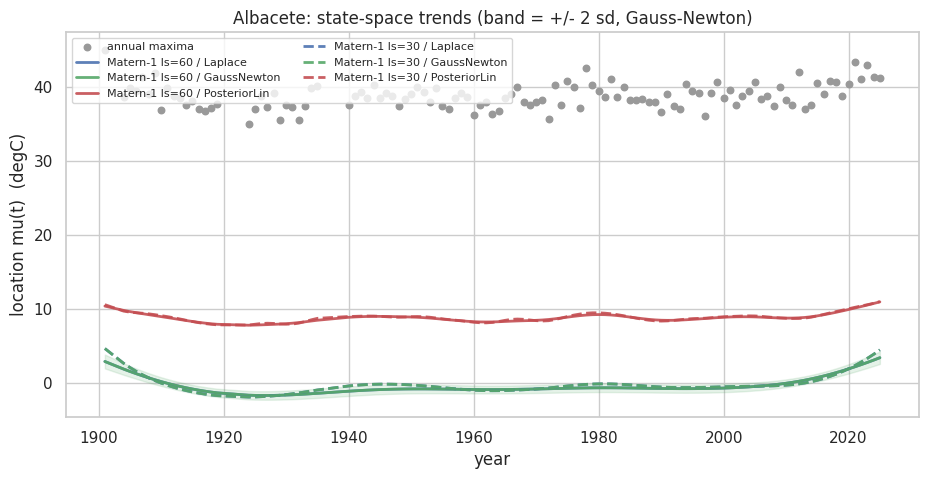

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(yr, y_np, s=22, color="0.6", zorder=2, label="annual maxima")
palette = {"Laplace": "#4C72B0", "GaussNewton": "#55A868", "PosteriorLin": "#C44E52"}
for key, (mu_t, sd_t) in curves.items():
    if "order=2" in key or "Matern-2" in key:
        continue
    sname = key.split("/ ")[-1]
    ls_style = "-" if "ls=60" in key else "--"
    ax.plot(yr, mu_t, ls_style, lw=2, color=palette[sname], alpha=0.9,
            label=key)
ref = [k for k in curves if "Matern-1 ls=60 / GaussNewton" in k]
if ref:
    mu_t, sd_t = curves[ref[0]]
    ax.fill_between(yr, mu_t - 2 * sd_t, mu_t + 2 * sd_t, color="#55A868",
                    alpha=0.15, zorder=1)
ax.set(xlabel="year", ylabel="location mu(t)  (degC)",
       title=f"{meta['name']}: state-space trends (band = +/- 2 sd, Gauss-Newton)")
ax.legend(fontsize=8, ncol=2, loc="upper left")
plt.show()

## The over-fitting question

Notebook 12 ran a deliberate cautionary experiment: it gave a **stationary**
Matern trend a free lengthscale and let NUTS fit it. The result was a curve that
chased individual hot years, with a WAIC far better in-sample than any of the
honest models — the classic signature of over-fitting a short record.

That experiment is often read as "stationary kernels over-fit here". The sweep
above suggests a more precise reading: what over-fits is a **free lengthscale**,
not stationarity itself. With the lengthscale pinned at a few decades — a choice
made from what we believe about climate, not from the 115 points — the
stationary Matern produces a trend that agrees with the local linear trend to
within a tenth of a degree.

The comparison below makes the difference concrete: the same kernel family at a
short lengthscale is exactly the wiggly curve notebook 12 warned about.


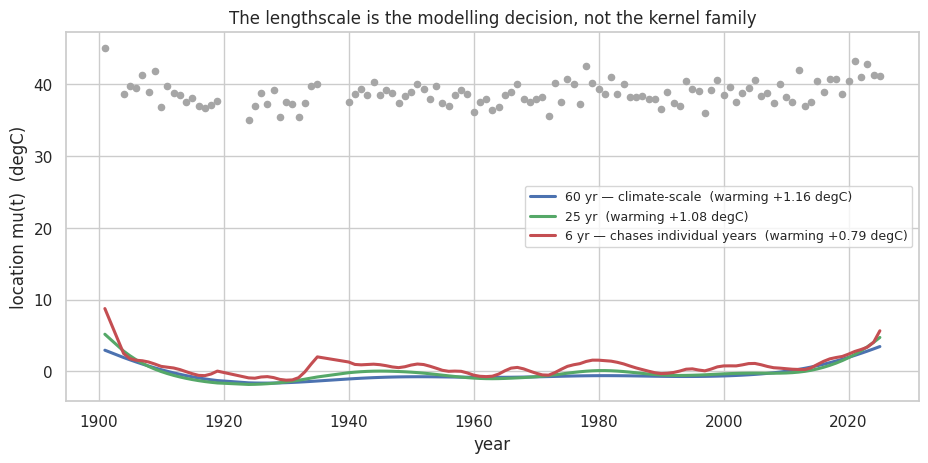

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.scatter(yr, y_np, s=20, color="0.65", zorder=2)
for ls, col, lab in ((60.0, "#4C72B0", "60 yr — climate-scale"),
                     (25.0, "#55A868", "25 yr"),
                     (6.0, "#C44E52", "6 yr — chases individual years")):
    sde = P.MaternSDE(variance=jnp.asarray(4.0), lengthscale=jnp.asarray(ls), order=1)
    prior = P.MarkovGPPrior(sde_kernel=sde, times=times)
    with numpyro.handlers.seed(rng_seed=0):
        cond = prior.condition_nongauss(lik, y_centred,
                                        strategy=P.GaussNewtonMarkovInference())
        m, _ = cond.predict(times)
    mu_t = np.asarray(m) + y_mean
    ax.plot(yr, mu_t, lw=2.2, color=col,
            label=f"{lab}  (warming {mu_t[-15:].mean() - mu_t[:15].mean():+.2f} degC)")
ax.set(xlabel="year", ylabel="location mu(t)  (degC)",
       title="The lengthscale is the modelling decision, not the kernel family")
ax.legend(fontsize=9)
plt.show()

## Takeaway

**The state-space route is much cheaper, and here it agrees.** Kalman-based
inference recovered essentially notebook 12's warming estimate in tens of
seconds rather than the several minutes NUTS needed for the path — an order of
magnitude, on a problem where the two answers land within about a tenth of a
degree of each other.

**But it is not a drop-in replacement, for two reasons.**

First, the prior changed. The local linear trend is non-stationary by
construction: it encodes "smooth, and linear unless the data push back" without
committing to a scale. A stationary Matern needs a lengthscale, and that number
is doing real work — the last figure shows the same kernel family producing
anything from a climate trend to a curve chasing individual summers. Notebook 12
never had to choose it. That is a genuine advantage of its hand-rolled prior,
and the reason `MarkovGPPrior` cannot simply replace it: **no integrated-Wiener
SDE kernel exists in the library**, and a stationary one is not the same model.

Second, the comparison held $\sigma$, $\xi$ and the kernel hyperparameters
fixed, where notebook 12 inferred them jointly with the trend. The speed-up is
real but flattered: some of what NUTS was paying for is uncertainty this
calculation never propagates. The honest summary is that Kalman inference is
the right tool for the *path given the hyperparameters*, and the interesting
design would be to nest it inside an outer loop over them.

**One incidental correction.** Notebook 12's over-fitting demonstration is
usually read as an argument against stationary kernels. The sweep here suggests
it is really an argument against **free lengthscales on short records**. Pinned
at a climate-appropriate scale, the stationary kernel behaves. That distinction
matters, because it points at the fix — put a prior on the lengthscale, or
choose it from physical reasoning — rather than at abandoning a whole kernel
family.

### A gap worth filing

An integrated-Wiener / local-linear-trend SDE kernel would let this notebook and
notebook 12 be the same model fitted two ways, which is the comparison one
actually wants. It is a small addition to the SDE kernel family — the state
transition and process noise are both standard — and it would make the entire
state-space stack usable for trend estimation, which is one of its most common
applications.
